In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

## 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 가져옴

In [60]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
# quiz에서는 scale조정, train_test_split 등을 추가
from sklearn.metrics import confusion_matrix

In [3]:
import numpy as np
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [4]:
print('타겟 :', data[0,0])
# print('이미지(28*28을 1차원으로) :', data[0, 1:].reshape(28,28))

타겟 : 5.0


In [5]:
for row in data[1, 1:].reshape(28,28):
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51159253159 50  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 48238252252252237  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 54227253252239233252 57  6  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 10 60224252253252202 84252253122  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0163252252252253252252 96189253167  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 51238253253190114253228 47 79255168  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 48238252252179 12 75121 21  0  0253243 50  0  0  0  0  0
  0  0  0  0  0  0  0  0 38165253233208 84  0  0  0  0  0  025325

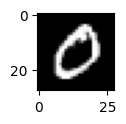

In [6]:
plt.figure(figsize=(1,1))
plt.imshow(data[1, 1:].reshape(28,28), cmap='gray')

In [7]:
# %pip install opencv-contrib-python

In [8]:
# %pip install opencv-python

In [9]:
! pip show opencv-contrib-python

Name: opencv-contrib-python
Version: 4.11.0.86
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\users\admin\anaconda3\lib\site-packages
Requires: numpy, numpy, numpy, numpy
Required-by: 


In [10]:
! pip show opencv-python

Name: opencv-python
Version: 4.11.0.86
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\users\admin\anaconda3\lib\site-packages
Requires: numpy, numpy, numpy, numpy
Required-by: 


In [11]:
# 칼라사진 -> 흑백모드의 넘파이 배열로
import cv2
image_gray = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE) # 흑백포맷으로 읽기
print(image_gray.shape)
print(type(image_gray))

(166, 303)
<class 'numpy.ndarray'>


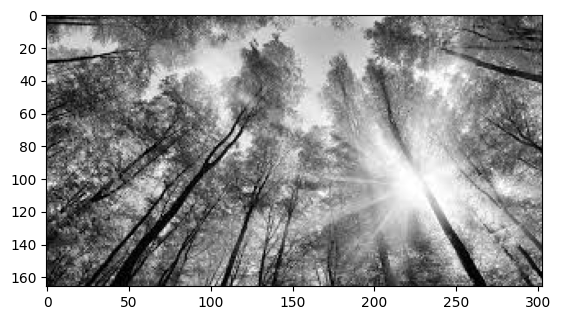

In [12]:
plt.imshow(image_gray, cmap='gray')

# 1. 데이터 생성 및 전처리

In [13]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [14]:
for row in X_train[0]:
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

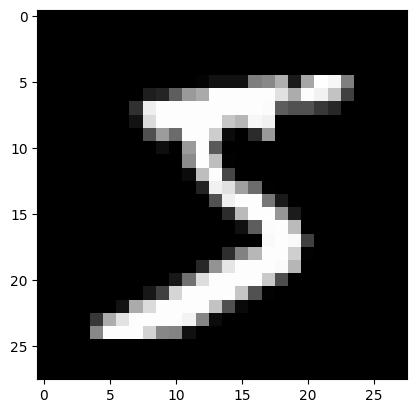

In [15]:
plt.imshow(X_train[0], cmap='gray')

In [16]:
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [17]:
# 학습셋(5만개:fit용), 검증셋(만:fit용), 테스트셋(만:평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


In [18]:
# 입력(독립)변수 (n, 28,28) -> (n, 784) -> 실수형변환 -> 스케일조정(255.0으로 나눠)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [19]:
# 훈련셋5만개 -> 700개, 테스트셋 1만개 -> 300개 추출(목적 : 학습시간 절약), 테스트셋은 그대로
train_idx = np.random.choice(50000, 700)
val_idx = np.random.choice(10000,300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
train_X.shape, y_train.shape, val_X.shape, y_val.shape

((700, 784), (700,), (300, 784), (300,))

In [22]:
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
print(y_train[:2])
print(train_Y[:2])

[4 9]
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [23]:
# 데이터 처리 전 작업
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_idx = np.random.choice(50000, 700)
val_idx = np.random.choice(10000,300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델구성

In [24]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 1570      
                                                                 
 dense_1 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 3.학습과정 설정

In [25]:
model.compile(loss='categorical_crossentropy', # spare_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])

# 4. 모델 학습

In [26]:
%%time
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y))

Epoch 1/500
7/7 [==============================] - 1s 41ms/step - loss: 2.2980 - accuracy: 0.1043 - val_loss: 2.2745 - val_accuracy: 0.1800
Epoch 2/500
7/7 [==============================] - 0s 8ms/step - loss: 2.2656 - accuracy: 0.1429 - val_loss: 2.2500 - val_accuracy: 0.2000
Epoch 3/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2452 - accuracy: 0.1414 - val_loss: 2.2284 - val_accuracy: 0.1867
Epoch 4/500
7/7 [==============================] - 0s 8ms/step - loss: 2.2238 - accuracy: 0.1471 - val_loss: 2.2025 - val_accuracy: 0.1933
Epoch 5/500
7/7 [==============================] - 0s 8ms/step - loss: 2.2013 - accuracy: 0.1643 - val_loss: 2.1800 - val_accuracy: 0.1967
Epoch 6/500
7/7 [==============================] - 0s 9ms/step - loss: 2.1830 - accuracy: 0.1743 - val_loss: 2.1604 - val_accuracy: 0.2033
Epoch 7/500
7/7 [==============================] - 0s 9ms/step - loss: 2.1652 - accuracy: 0.1971 - val_loss: 2.1414 - val_accuracy: 0.2167
Epoch 8/500
7/7 [=========

7/7 [==============================] - 0s 9ms/step - loss: 1.5775 - accuracy: 0.3914 - val_loss: 1.6874 - val_accuracy: 0.3533
Epoch 60/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5707 - accuracy: 0.3971 - val_loss: 1.6830 - val_accuracy: 0.3533
Epoch 61/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5646 - accuracy: 0.3957 - val_loss: 1.6786 - val_accuracy: 0.3533
Epoch 62/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5582 - accuracy: 0.3957 - val_loss: 1.6744 - val_accuracy: 0.3567
Epoch 63/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5519 - accuracy: 0.3929 - val_loss: 1.6705 - val_accuracy: 0.3567
Epoch 64/500
7/7 [==============================] - 0s 8ms/step - loss: 1.5456 - accuracy: 0.3971 - val_loss: 1.6666 - val_accuracy: 0.3533
Epoch 65/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5399 - accuracy: 0.4014 - val_loss: 1.6627 - val_accuracy: 0.3533
Epoch 66/500
7/7 [===============

7/7 [==============================] - 0s 7ms/step - loss: 1.3164 - accuracy: 0.4714 - val_loss: 1.5452 - val_accuracy: 0.4000
Epoch 118/500
7/7 [==============================] - 0s 9ms/step - loss: 1.3136 - accuracy: 0.4686 - val_loss: 1.5440 - val_accuracy: 0.3900
Epoch 119/500
7/7 [==============================] - 0s 8ms/step - loss: 1.3101 - accuracy: 0.4757 - val_loss: 1.5414 - val_accuracy: 0.4033
Epoch 120/500
7/7 [==============================] - 0s 12ms/step - loss: 1.3077 - accuracy: 0.4729 - val_loss: 1.5401 - val_accuracy: 0.4100
Epoch 121/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3041 - accuracy: 0.4771 - val_loss: 1.5399 - val_accuracy: 0.4033
Epoch 122/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3011 - accuracy: 0.4814 - val_loss: 1.5385 - val_accuracy: 0.4067
Epoch 123/500
7/7 [==============================] - 0s 8ms/step - loss: 1.2983 - accuracy: 0.4843 - val_loss: 1.5369 - val_accuracy: 0.4100
Epoch 124/500
7/7 [=======

7/7 [==============================] - 0s 8ms/step - loss: 1.1661 - accuracy: 0.5400 - val_loss: 1.4922 - val_accuracy: 0.4400
Epoch 176/500
7/7 [==============================] - 0s 8ms/step - loss: 1.1645 - accuracy: 0.5386 - val_loss: 1.4916 - val_accuracy: 0.4433
Epoch 177/500
7/7 [==============================] - 0s 7ms/step - loss: 1.1617 - accuracy: 0.5486 - val_loss: 1.4912 - val_accuracy: 0.4400
Epoch 178/500
7/7 [==============================] - 0s 7ms/step - loss: 1.1598 - accuracy: 0.5514 - val_loss: 1.4901 - val_accuracy: 0.4400
Epoch 179/500
7/7 [==============================] - 0s 7ms/step - loss: 1.1575 - accuracy: 0.5429 - val_loss: 1.4901 - val_accuracy: 0.4367
Epoch 180/500
7/7 [==============================] - 0s 7ms/step - loss: 1.1553 - accuracy: 0.5471 - val_loss: 1.4897 - val_accuracy: 0.4467
Epoch 181/500
7/7 [==============================] - 0s 8ms/step - loss: 1.1539 - accuracy: 0.5500 - val_loss: 1.4903 - val_accuracy: 0.4300
Epoch 182/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 1.0464 - accuracy: 0.6271 - val_loss: 1.4643 - val_accuracy: 0.4767
Epoch 234/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0443 - accuracy: 0.6271 - val_loss: 1.4648 - val_accuracy: 0.4767
Epoch 235/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0422 - accuracy: 0.6286 - val_loss: 1.4643 - val_accuracy: 0.4800
Epoch 236/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0407 - accuracy: 0.6371 - val_loss: 1.4642 - val_accuracy: 0.4733
Epoch 237/500
7/7 [==============================] - 0s 6ms/step - loss: 1.0381 - accuracy: 0.6300 - val_loss: 1.4655 - val_accuracy: 0.4800
Epoch 238/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0367 - accuracy: 0.6257 - val_loss: 1.4653 - val_accuracy: 0.4800
Epoch 239/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0340 - accuracy: 0.6300 - val_loss: 1.4637 - val_accuracy: 0.4800
Epoch 240/500
7/7 [========

7/7 [==============================] - 0s 12ms/step - loss: 0.9091 - accuracy: 0.7200 - val_loss: 1.4316 - val_accuracy: 0.5600
Epoch 292/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9069 - accuracy: 0.7186 - val_loss: 1.4331 - val_accuracy: 0.5633
Epoch 293/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9056 - accuracy: 0.7186 - val_loss: 1.4311 - val_accuracy: 0.5633
Epoch 294/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9031 - accuracy: 0.7171 - val_loss: 1.4323 - val_accuracy: 0.5667
Epoch 295/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9014 - accuracy: 0.7186 - val_loss: 1.4354 - val_accuracy: 0.5667
Epoch 296/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8983 - accuracy: 0.7200 - val_loss: 1.4301 - val_accuracy: 0.5667
Epoch 297/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8962 - accuracy: 0.7171 - val_loss: 1.4316 - val_accuracy: 0.5633
Epoch 298/500
7/7 [=======

7/7 [==============================] - 0s 7ms/step - loss: 0.8098 - accuracy: 0.7386 - val_loss: 1.4467 - val_accuracy: 0.5400
Epoch 350/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8090 - accuracy: 0.7429 - val_loss: 1.4492 - val_accuracy: 0.5433
Epoch 351/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8078 - accuracy: 0.7429 - val_loss: 1.4513 - val_accuracy: 0.5467
Epoch 352/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8067 - accuracy: 0.7386 - val_loss: 1.4554 - val_accuracy: 0.5467
Epoch 353/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8052 - accuracy: 0.7429 - val_loss: 1.4481 - val_accuracy: 0.5333
Epoch 354/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8038 - accuracy: 0.7400 - val_loss: 1.4491 - val_accuracy: 0.5433
Epoch 355/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8025 - accuracy: 0.7457 - val_loss: 1.4518 - val_accuracy: 0.5400
Epoch 356/500
7/7 [========

7/7 [==============================] - 0s 10ms/step - loss: 0.7458 - accuracy: 0.7514 - val_loss: 1.4785 - val_accuracy: 0.5333
Epoch 408/500
7/7 [==============================] - 0s 10ms/step - loss: 0.7450 - accuracy: 0.7529 - val_loss: 1.4810 - val_accuracy: 0.5400
Epoch 409/500
7/7 [==============================] - 0s 12ms/step - loss: 0.7441 - accuracy: 0.7514 - val_loss: 1.4831 - val_accuracy: 0.5400
Epoch 410/500
7/7 [==============================] - 0s 10ms/step - loss: 0.7436 - accuracy: 0.7514 - val_loss: 1.4802 - val_accuracy: 0.5333
Epoch 411/500
7/7 [==============================] - 0s 9ms/step - loss: 0.7418 - accuracy: 0.7543 - val_loss: 1.4833 - val_accuracy: 0.5400
Epoch 412/500
7/7 [==============================] - 0s 8ms/step - loss: 0.7413 - accuracy: 0.7557 - val_loss: 1.4833 - val_accuracy: 0.5400
Epoch 413/500
7/7 [==============================] - 0s 8ms/step - loss: 0.7405 - accuracy: 0.7543 - val_loss: 1.4820 - val_accuracy: 0.5333
Epoch 414/500
7/7 [====

7/7 [==============================] - 0s 8ms/step - loss: 0.6970 - accuracy: 0.7729 - val_loss: 1.5230 - val_accuracy: 0.5300
Epoch 466/500
7/7 [==============================] - 0s 9ms/step - loss: 0.6961 - accuracy: 0.7729 - val_loss: 1.5232 - val_accuracy: 0.5300
Epoch 467/500
7/7 [==============================] - 0s 9ms/step - loss: 0.6954 - accuracy: 0.7729 - val_loss: 1.5240 - val_accuracy: 0.5400
Epoch 468/500
7/7 [==============================] - 0s 8ms/step - loss: 0.6946 - accuracy: 0.7757 - val_loss: 1.5250 - val_accuracy: 0.5367
Epoch 469/500
7/7 [==============================] - 0s 8ms/step - loss: 0.6938 - accuracy: 0.7700 - val_loss: 1.5234 - val_accuracy: 0.5333
Epoch 470/500
7/7 [==============================] - 0s 7ms/step - loss: 0.6935 - accuracy: 0.7757 - val_loss: 1.5264 - val_accuracy: 0.5367
Epoch 471/500
7/7 [==============================] - 0s 8ms/step - loss: 0.6927 - accuracy: 0.7743 - val_loss: 1.5275 - val_accuracy: 0.5367
Epoch 472/500
7/7 [========

In [27]:
# 학습 과정 살펴보기
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

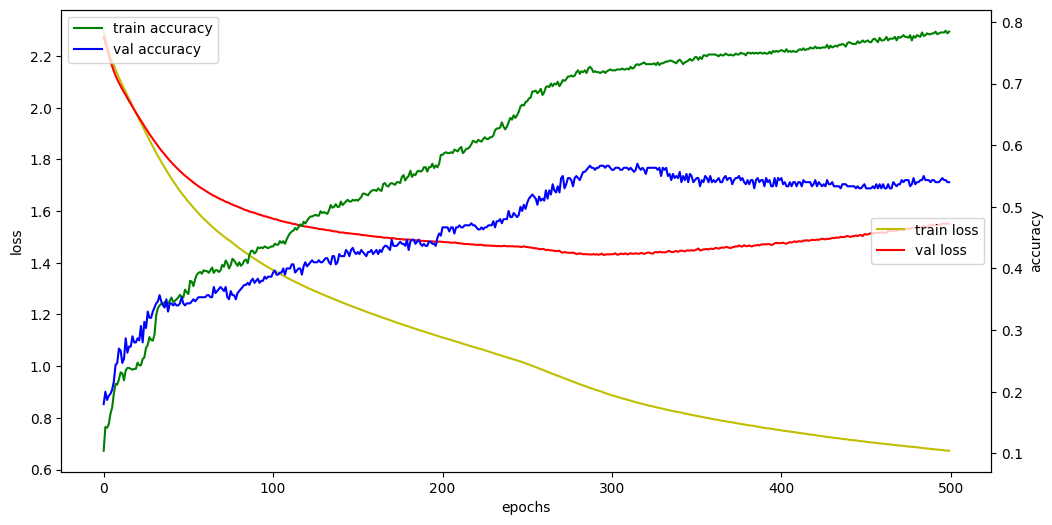

In [28]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [31]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 1.6840152740478516
accuracy : 0.5562000274658203


# 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, dropout, 활성화함수relu계열, tanh)
- epoch 조정
- optimizer 변경

Epoch 1/500
20/20 [==============================] - 0s 10ms/step - loss: 2.2986 - accuracy: 0.1055 - val_loss: 2.2698 - val_accuracy: 0.1693
Epoch 2/500
20/20 [==============================] - 0s 4ms/step - loss: 2.2282 - accuracy: 0.1480 - val_loss: 2.1667 - val_accuracy: 0.1507
Epoch 3/500
20/20 [==============================] - 0s 4ms/step - loss: 2.1401 - accuracy: 0.1805 - val_loss: 2.0784 - val_accuracy: 0.2413
Epoch 4/500
20/20 [==============================] - 0s 4ms/step - loss: 2.0659 - accuracy: 0.2540 - val_loss: 2.0114 - val_accuracy: 0.3080
Epoch 5/500
20/20 [==============================] - 0s 4ms/step - loss: 2.0111 - accuracy: 0.2955 - val_loss: 1.9637 - val_accuracy: 0.3233
Epoch 6/500
20/20 [==============================] - 0s 4ms/step - loss: 1.9714 - accuracy: 0.3050 - val_loss: 1.9280 - val_accuracy: 0.3420
Epoch 7/500
20/20 [==============================] - 0s 4ms/step - loss: 1.9376 - accuracy: 0.3175 - val_loss: 1.8982 - val_accuracy: 0.3440
Epoch 8/500


Epoch 59/500
20/20 [==============================] - 0s 4ms/step - loss: 1.3715 - accuracy: 0.5560 - val_loss: 1.4369 - val_accuracy: 0.5407
Epoch 60/500
20/20 [==============================] - 0s 4ms/step - loss: 1.3669 - accuracy: 0.5580 - val_loss: 1.4320 - val_accuracy: 0.5427
Epoch 61/500
20/20 [==============================] - 0s 3ms/step - loss: 1.3622 - accuracy: 0.5605 - val_loss: 1.4316 - val_accuracy: 0.5433
Epoch 62/500
20/20 [==============================] - 0s 3ms/step - loss: 1.3577 - accuracy: 0.5615 - val_loss: 1.4272 - val_accuracy: 0.5420
Epoch 63/500
20/20 [==============================] - 0s 4ms/step - loss: 1.3539 - accuracy: 0.5605 - val_loss: 1.4259 - val_accuracy: 0.5413
Epoch 64/500
20/20 [==============================] - 0s 3ms/step - loss: 1.3483 - accuracy: 0.5595 - val_loss: 1.4259 - val_accuracy: 0.5493
Epoch 65/500
20/20 [==============================] - 0s 4ms/step - loss: 1.3443 - accuracy: 0.5600 - val_loss: 1.4207 - val_accuracy: 0.5480
Epoch 

20/20 [==============================] - 0s 4ms/step - loss: 1.1893 - accuracy: 0.6050 - val_loss: 1.3725 - val_accuracy: 0.5693
Epoch 117/500
20/20 [==============================] - 0s 3ms/step - loss: 1.1882 - accuracy: 0.6000 - val_loss: 1.3796 - val_accuracy: 0.5707
Epoch 118/500
20/20 [==============================] - 0s 4ms/step - loss: 1.1869 - accuracy: 0.6000 - val_loss: 1.3707 - val_accuracy: 0.5653
Epoch 119/500
20/20 [==============================] - 0s 4ms/step - loss: 1.1811 - accuracy: 0.6025 - val_loss: 1.3711 - val_accuracy: 0.5667
Epoch 120/500
20/20 [==============================] - 0s 4ms/step - loss: 1.1794 - accuracy: 0.6030 - val_loss: 1.3752 - val_accuracy: 0.5687
Epoch 121/500
20/20 [==============================] - 0s 4ms/step - loss: 1.1778 - accuracy: 0.6030 - val_loss: 1.3722 - val_accuracy: 0.5687
Epoch 122/500
20/20 [==============================] - 0s 4ms/step - loss: 1.1753 - accuracy: 0.6015 - val_loss: 1.3712 - val_accuracy: 0.5680
Epoch 123/500

20/20 [==============================] - 0s 4ms/step - loss: 1.0931 - accuracy: 0.6310 - val_loss: 1.3905 - val_accuracy: 0.5627
Epoch 174/500
20/20 [==============================] - 0s 4ms/step - loss: 1.0929 - accuracy: 0.6300 - val_loss: 1.3882 - val_accuracy: 0.5620
Epoch 175/500
20/20 [==============================] - 0s 3ms/step - loss: 1.0910 - accuracy: 0.6330 - val_loss: 1.3816 - val_accuracy: 0.5573
Epoch 176/500
20/20 [==============================] - 0s 4ms/step - loss: 1.0902 - accuracy: 0.6330 - val_loss: 1.3883 - val_accuracy: 0.5620
Epoch 177/500
20/20 [==============================] - 0s 4ms/step - loss: 1.0888 - accuracy: 0.6330 - val_loss: 1.3834 - val_accuracy: 0.5600
Epoch 178/500
20/20 [==============================] - 0s 3ms/step - loss: 1.0875 - accuracy: 0.6340 - val_loss: 1.3881 - val_accuracy: 0.5613
Epoch 179/500
20/20 [==============================] - 0s 4ms/step - loss: 1.0862 - accuracy: 0.6345 - val_loss: 1.3863 - val_accuracy: 0.5640
Epoch 180/500

20/20 [==============================] - 0s 3ms/step - loss: 1.0355 - accuracy: 0.6490 - val_loss: 1.4299 - val_accuracy: 0.5580
Epoch 231/500
20/20 [==============================] - 0s 3ms/step - loss: 1.0351 - accuracy: 0.6510 - val_loss: 1.4279 - val_accuracy: 0.5580
Epoch 232/500
20/20 [==============================] - 0s 3ms/step - loss: 1.0340 - accuracy: 0.6560 - val_loss: 1.4265 - val_accuracy: 0.5547
Epoch 233/500
20/20 [==============================] - 0s 3ms/step - loss: 1.0326 - accuracy: 0.6535 - val_loss: 1.4415 - val_accuracy: 0.5600
Epoch 234/500
20/20 [==============================] - 0s 4ms/step - loss: 1.0328 - accuracy: 0.6470 - val_loss: 1.4383 - val_accuracy: 0.5580
Epoch 235/500
20/20 [==============================] - 0s 4ms/step - loss: 1.0313 - accuracy: 0.6560 - val_loss: 1.4359 - val_accuracy: 0.5580
Epoch 236/500
20/20 [==============================] - 0s 4ms/step - loss: 1.0295 - accuracy: 0.6550 - val_loss: 1.4328 - val_accuracy: 0.5580
Epoch 237/500

20/20 [==============================] - 0s 4ms/step - loss: 0.9940 - accuracy: 0.6670 - val_loss: 1.4835 - val_accuracy: 0.5580
Epoch 288/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9925 - accuracy: 0.6660 - val_loss: 1.4811 - val_accuracy: 0.5527
Epoch 289/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9920 - accuracy: 0.6665 - val_loss: 1.4902 - val_accuracy: 0.5573
Epoch 290/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9924 - accuracy: 0.6685 - val_loss: 1.4830 - val_accuracy: 0.5567
Epoch 291/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9911 - accuracy: 0.6675 - val_loss: 1.4860 - val_accuracy: 0.5520
Epoch 292/500
20/20 [==============================] - 0s 3ms/step - loss: 0.9896 - accuracy: 0.6675 - val_loss: 1.4921 - val_accuracy: 0.5553
Epoch 293/500
20/20 [==============================] - 0s 3ms/step - loss: 0.9891 - accuracy: 0.6700 - val_loss: 1.4882 - val_accuracy: 0.5553
Epoch 294/500

20/20 [==============================] - 0s 5ms/step - loss: 0.9630 - accuracy: 0.6780 - val_loss: 1.5300 - val_accuracy: 0.5547
Epoch 345/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9623 - accuracy: 0.6790 - val_loss: 1.5467 - val_accuracy: 0.5560
Epoch 346/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9611 - accuracy: 0.6835 - val_loss: 1.5404 - val_accuracy: 0.5600
Epoch 347/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9605 - accuracy: 0.6825 - val_loss: 1.5578 - val_accuracy: 0.5587
Epoch 348/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9597 - accuracy: 0.6820 - val_loss: 1.5537 - val_accuracy: 0.5640
Epoch 349/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9586 - accuracy: 0.6825 - val_loss: 1.5539 - val_accuracy: 0.5620
Epoch 350/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9584 - accuracy: 0.6815 - val_loss: 1.5557 - val_accuracy: 0.5580
Epoch 351/500

20/20 [==============================] - 0s 4ms/step - loss: 0.9339 - accuracy: 0.6845 - val_loss: 1.6057 - val_accuracy: 0.5553
Epoch 402/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9346 - accuracy: 0.6855 - val_loss: 1.6047 - val_accuracy: 0.5553
Epoch 403/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9337 - accuracy: 0.6845 - val_loss: 1.6104 - val_accuracy: 0.5567
Epoch 404/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9342 - accuracy: 0.6845 - val_loss: 1.6043 - val_accuracy: 0.5573
Epoch 405/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9332 - accuracy: 0.6835 - val_loss: 1.6085 - val_accuracy: 0.5553
Epoch 406/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9329 - accuracy: 0.6800 - val_loss: 1.6133 - val_accuracy: 0.5560
Epoch 407/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9319 - accuracy: 0.6865 - val_loss: 1.6072 - val_accuracy: 0.5553
Epoch 408/500

20/20 [==============================] - 0s 4ms/step - loss: 0.9122 - accuracy: 0.6930 - val_loss: 1.6705 - val_accuracy: 0.5500
Epoch 459/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9125 - accuracy: 0.6960 - val_loss: 1.6679 - val_accuracy: 0.5507
Epoch 460/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9122 - accuracy: 0.6915 - val_loss: 1.6632 - val_accuracy: 0.5480
Epoch 461/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9123 - accuracy: 0.6905 - val_loss: 1.6796 - val_accuracy: 0.5507
Epoch 462/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9110 - accuracy: 0.6905 - val_loss: 1.6683 - val_accuracy: 0.5500
Epoch 463/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9110 - accuracy: 0.6910 - val_loss: 1.6678 - val_accuracy: 0.5500
Epoch 464/500
20/20 [==============================] - 0s 4ms/step - loss: 0.9106 - accuracy: 0.6910 - val_loss: 1.6792 - val_accuracy: 0.5533
Epoch 465/500

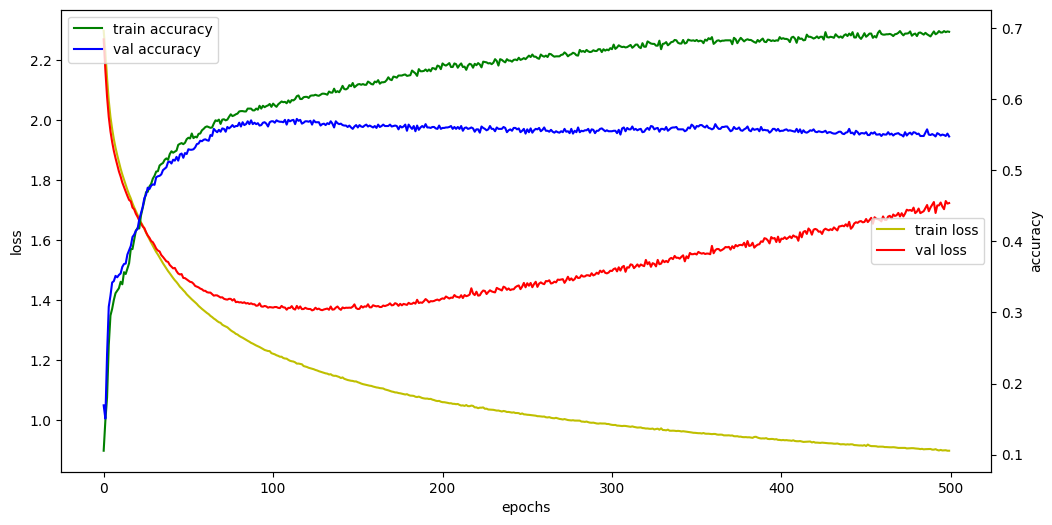

loss : 1.6140046119689941
accuracy : 0.5415999889373779
CPU times: total: 54.2 s
Wall time: 39.2 s


In [33]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000 -> 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 2000)
val_idx  = np.random.choice(10000, 1500)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 학습
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y))
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

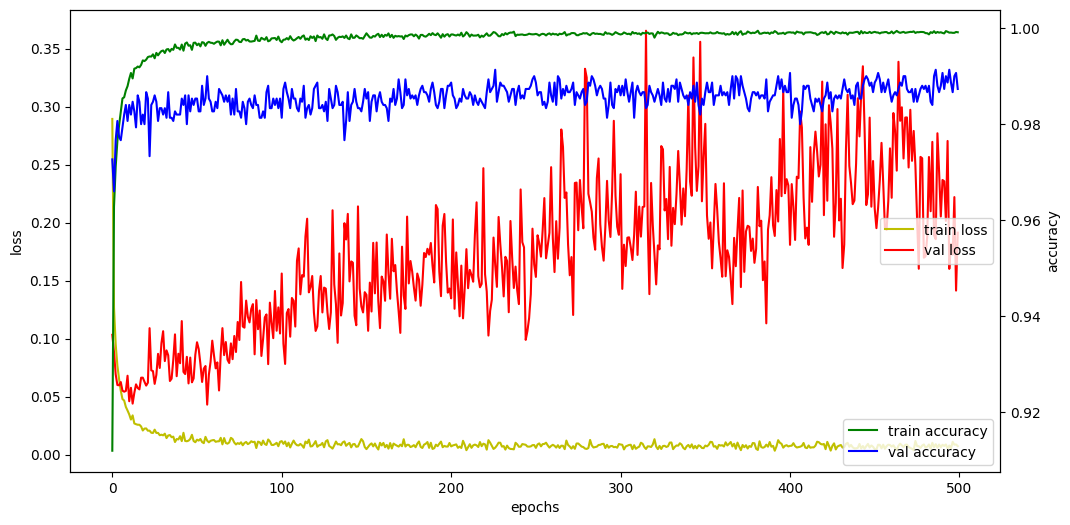

loss : 0.4649584889411926
accuracy : 0.9861999750137329
CPU times: total: 2h 29min 4s
Wall time: 37min 49s


In [43]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000 -> 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 50000, replace=False)
val_idx  = np.random.choice(10000, 1500)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 학습
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=64,
                validation_data=(val_X, val_Y),
                verbose=0)
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

Epoch 1/50
500/500 [==============================] - 16s 29ms/step - loss: 0.2693 - accuracy: 0.9167 - val_loss: 0.1068 - val_accuracy: 0.9685
Epoch 2/50
500/500 [==============================] - 16s 32ms/step - loss: 0.1249 - accuracy: 0.9619 - val_loss: 0.0956 - val_accuracy: 0.9713
Epoch 3/50
500/500 [==============================] - 17s 34ms/step - loss: 0.0929 - accuracy: 0.9714 - val_loss: 0.0896 - val_accuracy: 0.9742
Epoch 4/50
500/500 [==============================] - 14s 29ms/step - loss: 0.0771 - accuracy: 0.9763 - val_loss: 0.0826 - val_accuracy: 0.9761
Epoch 5/50
500/500 [==============================] - 16s 32ms/step - loss: 0.0694 - accuracy: 0.9782 - val_loss: 0.0827 - val_accuracy: 0.9756
Epoch 6/50
500/500 [==============================] - 17s 33ms/step - loss: 0.0610 - accuracy: 0.9801 - val_loss: 0.0884 - val_accuracy: 0.9772
Epoch 7/50
500/500 [==============================] - 15s 30ms/step - loss: 0.0580 - accuracy: 0.9819 - val_loss: 0.0760 - val_accuracy:

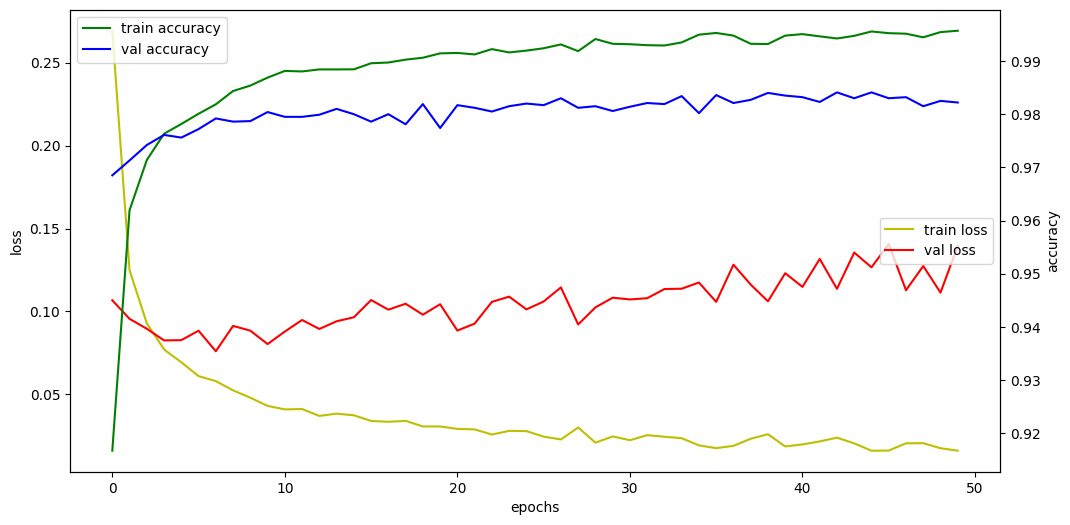

CPU times: total: 1h 7min 54s
Wall time: 12min 46s


In [44]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개 / 10000개 -> 300
# train_idx = np.random.choice(50000, 700)
# val_idx  = np.random.choice(10000, 300)
# train_X = train_X[train_idx]
# y_train = y_train[train_idx]
# val_X   = val_X[val_idx]
# y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu')) # tanh, relu, elu, gelu
model.add(Dropout(0.3))
model.add(Dense(units=512, activation='elu'))
model.add(Dropout(0.3))
model.add(Dense(units=256)) #  activation='leakyrelu'사용불가
from tensorflow.keras.layers import LeakyReLU
model.add(LeakyReLU(alpha=0.01)) 
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1)
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [54]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 0.11768635362386703
accuracy : 0.983299970626831


In [55]:
# 실제값
test_Y.argmax(axis=1) == y_test

array([ True,  True,  True, ...,  True,  True,  True])

In [56]:
# 예측값
yhat = model.predict(test_X).argmax(axis=1)
yhat = np.argmax(model.predict(test_X), axis=1)
yhat

313/313 [==============================] - 1s 4ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [57]:
pd.crosstab(y_test, yhat)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,971,1,0,1,1,1,2,2,1,0
1,0,1127,1,0,1,2,2,1,1,0
2,0,0,1020,1,1,0,1,5,4,0
3,0,0,7,985,0,6,0,2,1,9
4,2,0,1,0,957,0,3,2,1,16
5,2,0,0,1,0,880,3,0,0,6
6,2,2,0,0,2,5,942,0,5,0
7,0,2,6,0,0,0,0,1011,1,8
8,2,1,2,3,2,7,0,3,945,9


In [62]:
confusion_matrix(y_test, yhat)

array([[ 971,    1,    0,    1,    1,    1,    2,    2,    1,    0],
       [   0, 1127,    1,    0,    1,    2,    2,    1,    1,    0],
       [   0,    0, 1020,    1,    1,    0,    1,    5,    4,    0],
       [   0,    0,    7,  985,    0,    6,    0,    2,    1,    9],
       [   2,    0,    1,    0,  957,    0,    3,    2,    1,   16],
       [   2,    0,    0,    1,    0,  880,    3,    0,    0,    6],
       [   2,    2,    0,    0,    2,    5,  942,    0,    5,    0],
       [   0,    2,    6,    0,    0,    0,    0, 1011,    1,    8],
       [   2,    1,    2,    3,    2,    7,    0,    3,  945,    9],
       [   1,    2,    1,    1,    5,    1,    1,    2,    0,  995]],
      dtype=int64)

In [63]:
# 틀린 갯수:
10000- 10000*loss_and_metrics[1]

167.00029373168945

In [64]:
cnt =0
for y, h in zip(y_test, yhat):
    if y!=h:
        cnt += 1
print('틀린 갯수 :', cnt)

틀린 갯수 : 167


In [65]:
# 모델 저장
model.save('model/08_mnist.h5')

# ※ 콜백함수1 : 로그 출력

In [66]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [74]:
%%time
# 매번 로그 출력하면 지저분해 질 수 있으니, 특정 에포크마다 로그 출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}) : # 1 epoch마다 자동 실행되는 함수
        self.epoch += 1 # epoch마다 self.epoch값을 1씩 증가
        if self.epoch%10 ==0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{}'.\
                  format(self.epoch,
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')
                        )
                 )

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu')) # tanh, relu, elu, gelu
model.add(Dropout(0.3))
model.add(Dense(units=512, activation='elu'))
model.add(Dropout(0.3))
model.add(Dense(units=256)) #  activation='leakyrelu'사용불가
from tensorflow.keras.layers import LeakyReLU
model.add(LeakyReLU(alpha=0.01)) 
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
customHistory = CustomHistory()
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistory]) # 콜백함수

epoch:10, loss:0.04832806810736656, acc:0.9928571581840515, val_loss:0.6769149303436279, val_acc:0.8633333444595337
epoch:20, loss:0.012240833602845669, acc:0.9971428513526917, val_loss:0.708787739276886, val_acc:0.8700000047683716
epoch:30, loss:0.020476248115301132, acc:0.991428554058075, val_loss:0.8111894726753235, val_acc:0.8666666746139526
epoch:40, loss:0.01181136816740036, acc:0.9971428513526917, val_loss:0.7976537346839905, val_acc:0.8866666555404663
epoch:50, loss:0.0011249720118939877, acc:1.0, val_loss:0.8149835467338562, val_acc:0.8766666650772095
CPU times: total: 1min 1s
Wall time: 12 s


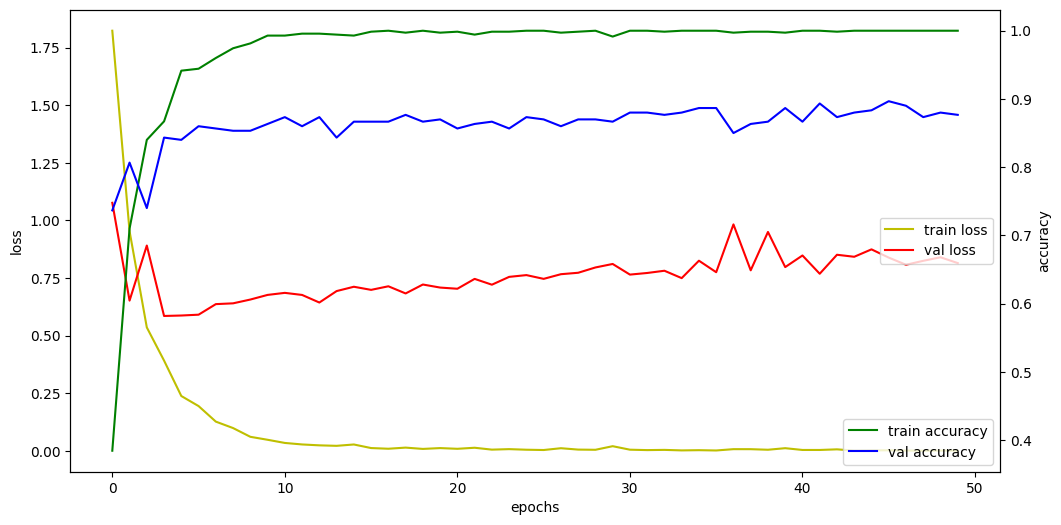

In [75]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# ※ 콜백함수2 : EarlyStopping
- val_loss값이 늘어면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [76]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=2) 
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping]) # 콜백함수

Epoch 1/500
7/7 [==============================] - 1s 24ms/step - loss: 2.2903 - accuracy: 0.1000 - val_loss: 2.2842 - val_accuracy: 0.1267
Epoch 2/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2727 - accuracy: 0.1171 - val_loss: 2.2681 - val_accuracy: 0.1100
Epoch 3/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2552 - accuracy: 0.1000 - val_loss: 2.2506 - val_accuracy: 0.1100


# ※ 콜백함수3 : ModelCheckpoint
- epoch마다 val_accuracy(val_loss, accuracy, loss)값이 좋을 때 모델을 자동 저장하는 콜백

In [77]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=2)
# 모델 자동 저장 콜백
import os
model_save_folder = './model08.'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'

checkpoint = ModelCheckpoint(filepath=file,
                            monitor='val_accuracy', # 모니터할 지표
                            save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                            mode = 'max', # 값이 클 수록 저장
                            verbose=1 # 저장시 로그 출력
                            )

hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping, checkpoint]) # 콜백함수

Epoch 1/500
1/7 [===>..........................] - ETA: 2s - loss: 2.3102 - accuracy: 0.1300
Epoch 1: val_accuracy improved from -inf to 0.12333, saving model to .\model08.mnist-001-val0.1233.h5
7/7 [==============================] - 1s 30ms/step - loss: 2.3094 - accuracy: 0.1129 - val_loss: 2.2986 - val_accuracy: 0.1233
Epoch 2/500
1/7 [===>..........................] - ETA: 0s - loss: 2.2934 - accuracy: 0.1300
Epoch 2: val_accuracy improved from 0.12333 to 0.16333, saving model to .\model08.mnist-002-val0.1633.h5
7/7 [==============================] - 0s 10ms/step - loss: 2.2937 - accuracy: 0.1529 - val_loss: 2.2762 - val_accuracy: 0.1633
Epoch 3/500
1/7 [===>..........................] - ETA: 0s - loss: 2.2827 - accuracy: 0.1500
Epoch 3: val_accuracy did not improve from 0.16333
7/7 [==============================] - 0s 8ms/step - loss: 2.2618 - accuracy: 0.1629 - val_loss: 2.2495 - val_accuracy: 0.1233
Epoch 4/500
1/7 [===>..........................] - ETA: 0s - loss: 2.2462 - accu

In [78]:
model.evaluate(val_X, val_Y)

10/10 [==============================] - 0s 2ms/step - loss: 2.2270 - accuracy: 0.1233


[2.227030038833618, 0.12333333492279053]